<a href="https://colab.research.google.com/github/arulperiyannagounder-collab/Training_Hands_on/blob/main/ANN_for_Stroke_data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv('/content/healthcare-dataset-stroke-data.csv')


In [ ]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
df.shape

(5110, 12)

In [ ]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [ ]:
df.columns.to_list()

['id',
 'gender',
 'age',
 'hypertension',
 'heart_disease',
 'ever_married',
 'work_type',
 'Residence_type',
 'avg_glucose_level',
 'bmi',
 'smoking_status',
 'stroke']

In [ ]:
x=df[['id',
 'gender',
 'age',
 'hypertension',
 'heart_disease',
 'ever_married',
 'work_type',
 'Residence_type',
 'avg_glucose_level',
 'bmi',
 'smoking_status']]
y=df['stroke']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(x,y)

In [ ]:
import pandas as pd


X_train_processed = X_train.copy()
X_test_processed = X_test.copy()


X_train_processed = X_train_processed.drop('id', axis=1)
X_test_processed = X_test_processed.drop('id', axis=1)


mean_bmi = X_train_processed['bmi'].mean()
X_train_processed['bmi'] = X_train_processed['bmi'].fillna(mean_bmi)
X_test_processed['bmi'] = X_test_processed['bmi'].fillna(mean_bmi)


categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


X_train_processed = pd.get_dummies(X_train_processed, columns=categorical_cols, drop_first=True)
X_test_processed = pd.get_dummies(X_test_processed, columns=categorical_cols, drop_first=True)


train_cols = X_train_processed.columns
test_cols = X_test_processed.columns

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test_processed[c] = 0

missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    X_train_processed[c] = 0


X_test_processed = X_test_processed[train_cols]


scaler = StandardScaler()


X_train = scaler.fit_transform(X_train_processed)
X_test = scaler.transform(X_test_processed)


In [ ]:
import tensorflow as tf
from tensorflow import keras


In [ ]:
model=keras.Sequential(
    [
        keras.layers.Flatten(input_shape=(16,)),
        keras.layers.Dense(20,activation='relu'),
        keras.layers.Dense(2,activation='sigmoid'),
    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(X_train,y_train,validation_split=0.1,epochs=10)


Epoch 1/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9481 - loss: 0.2645 - val_accuracy: 0.9479 - val_loss: 0.2203
Epoch 2/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9504 - loss: 0.1983 - val_accuracy: 0.9479 - val_loss: 0.1886
Epoch 3/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9501 - loss: 0.1789 - val_accuracy: 0.9479 - val_loss: 0.1760
Epoch 4/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9501 - loss: 0.1703 - val_accuracy: 0.9479 - val_loss: 0.1717
Epoch 5/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9501 - loss: 0.1657 - val_accuracy: 0.9479 - val_loss: 0.1690
Epoch 6/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9504 - loss: 0.1618 - val_accuracy: 0.9479 - val_loss: 0.1685
Epoch 7/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9504 - loss: 0.1594 - val_accuracy: 0.9479 - val_loss: 0.1677
Epoch 8/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9504 - loss: 0.1571 - val_accuracy: 0.

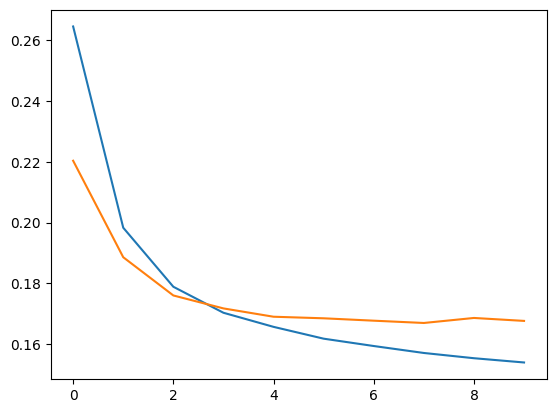

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

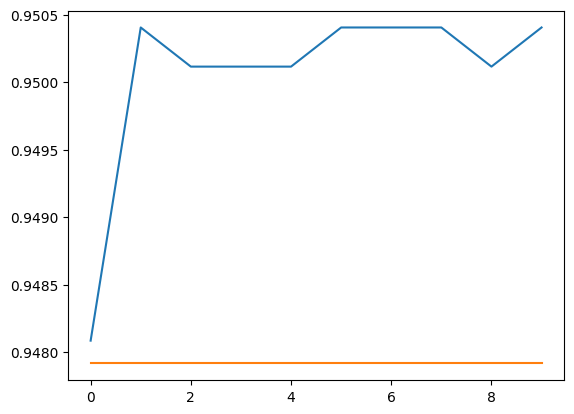

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])